# Instrumental Variables: Effect of Surge Pricing on Ride Completions (Uber)

## The Problem

Uber wants to know: **does surge pricing reduce ride completions?**

A naive regression of completions on surge price is biased because **unobserved factors** simultaneously drive both:
- **Events/concerts** → increase demand → trigger surge AND reduce completion (too many requests)
- **Trip urgency** → riders accept higher prices → surge stays high AND completions stay high
- **Driver supply shocks** → fewer drivers → surge rises AND completions drop

The OLS estimate confounds the causal effect of price with these demand/supply shocks.

## The Solution: Instrumental Variables

We use **rainfall** as an instrument for surge pricing:
- Rain → more ride requests → higher surge (relevance ✓)
- Rain doesn't affect whether a rider *completes* a ride once matched, except through price (exclusion ✓)
- Rain is weather — exogenous to demand shocks like events (independence ✓)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.sandbox.regression.gmm import IV2SLS

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')

print("Setup complete.")

Setup complete.


## Data Simulation & DAG

The causal structure:

```
        Rain (Instrument)
          │
          ▼
    Surge Price (Treatment) ──────► Ride Completions (Outcome)
          ▲                                    ▲
          │                                    │
          └──── Event Demand (Unobserved) ─────┘
```

**True causal effect of surge on completions = -0.15**  
(Each 1-unit increase in surge multiplier reduces completion rate by 15 percentage points)

In [2]:
n = 5000
TRUE_EFFECT = -0.15

# Instrument: rainfall (mm) — exogenous weather variation
rain = np.random.exponential(scale=2.0, size=n)

# Unmeasured confounder: event demand (0-1 scale)
# This drives BOTH surge and completions — the source of bias
event_demand = np.random.beta(2, 5, size=n)

# Treatment: surge multiplier
# Driven by rain (instrument) AND event demand (confounder)
surge = 1.0 + 0.3 * rain + 1.5 * event_demand + np.random.normal(0, 0.2, n)
surge = np.clip(surge, 1.0, 4.0)

# Outcome: ride completion rate
# Affected by surge (true causal effect) AND event demand (confounder)
completion_rate = (
    0.85  # baseline completion rate
    + TRUE_EFFECT * surge  # true causal effect of price
    - 0.20 * event_demand  # confounder effect (events reduce completions)
    + np.random.normal(0, 0.05, n)
)
completion_rate = np.clip(completion_rate, 0, 1)

df = pd.DataFrame({
    'rain': rain,
    'surge': surge,
    'completion_rate': completion_rate,
    'event_demand': event_demand  # we pretend we can't observe this
})

print(f"Simulated {n} ride-hours")
print(f"True causal effect of surge on completions: {TRUE_EFFECT}")
print(f"\nData summary:")
print(df[['rain', 'surge', 'completion_rate']].describe().round(3))

Simulated 5000 ride-hours
True causal effect of surge on completions: -0.15

Data summary:
           rain     surge  completion_rate
count  5000.000  5000.000         5000.000
mean      1.980     2.011            0.491
std       1.974     0.634            0.122
min       0.000     1.000            0.000
25%       0.559     1.564            0.418
50%       1.386     1.895            0.504
75%       2.757     2.319            0.578
max      16.345     4.000            0.787


## Naive OLS: Why It Fails

If we simply regress completions on surge, we get a biased estimate. The bias comes from the **omitted variable** (event demand) which is positively correlated with surge and negatively correlated with completions. This makes the OLS estimate *more negative* than the true effect.

In [3]:
# Naive OLS: completions ~ surge
X_ols = sm.add_constant(df['surge'])
ols_model = sm.OLS(df['completion_rate'], X_ols).fit()

print("=" * 60)
print("NAIVE OLS: Completions ~ Surge")
print("=" * 60)
print(f"\nOLS estimate of surge effect: {ols_model.params['surge']:.4f}")
print(f"True causal effect:            {TRUE_EFFECT:.4f}")
print(f"Bias (OLS - True):             {ols_model.params['surge'] - TRUE_EFFECT:.4f}")
print(f"\nThe OLS estimate is MORE NEGATIVE than truth.")
print(f"Why? Event demand ↑ surge AND ↓ completions → spurious negative correlation.")
print(f"\n{ols_model.summary().tables[1]}")

NAIVE OLS: Completions ~ Surge

OLS estimate of surge effect: -0.1689
True causal effect:            -0.1500
Bias (OLS - True):             -0.0189

The OLS estimate is MORE NEGATIVE than truth.
Why? Event demand ↑ surge AND ↓ completions → spurious negative correlation.

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.8302      0.003    304.600      0.000       0.825       0.836
surge         -0.1689      0.001   -130.637      0.000      -0.171      -0.166


## Why IV and Not Other Methods?

| Method | Why It Doesn't Work Here |
|--------|-------------------------|
| **Propensity Score Matching** | Requires observing ALL confounders. We cannot measure "event demand," "trip urgency," or "driver mood." Matching on observables still leaves bias from unobservables. |
| **Difference-in-Differences** | Requires a discrete intervention at a point in time. Surge pricing is continuous and happening constantly — there's no "pre" and "post" period for a single policy change. |
| **Regression Discontinuity** | Requires a sharp or fuzzy cutoff that determines treatment. Surge multipliers are set by a continuous algorithm — no threshold where treatment jumps discontinuously. |
| **Synthetic Control** | Designed for aggregate-level policy interventions with few treated units. Not applicable to continuous, unit-level pricing. |

**IV is the right choice** because we have an unmeasured confounder AND a plausible instrument (rainfall).

## Checking Instrument Validity

Three conditions must hold:

1. **Relevance**: Rain must predict surge (testable — first-stage F > 10)
2. **Exclusion**: Rain affects completions ONLY through surge (argue substantively)
3. **Independence**: Rain is uncorrelated with unobserved confounders (argue substantively)

In [4]:
# === RELEVANCE CHECK ===
# First stage: does rain predict surge?
X_first = sm.add_constant(df['rain'])
first_stage = sm.OLS(df['surge'], X_first).fit()

f_stat = first_stage.fvalue
print("=" * 60)
print("INSTRUMENT VALIDITY CHECKS")
print("=" * 60)
print(f"\n1. RELEVANCE (First Stage: Surge ~ Rain)")
print(f"   Coefficient on rain: {first_stage.params['rain']:.4f}")
print(f"   First-stage F-statistic: {f_stat:.1f}")
print(f"   Rule of thumb: F > 10 → {'PASS ✓' if f_stat > 10 else 'FAIL ✗'}")
print(f"   R-squared: {first_stage.rsquared:.4f}")

# === EXCLUSION RESTRICTION (argued, not tested) ===
print(f"\n2. EXCLUSION RESTRICTION (must argue substantively)")
print(f"   Claim: Rain → Surge → Completions (no direct Rain → Completions path)")
print(f"   Argument: Once a rider is matched with a driver, rain doesn't affect")
print(f"   whether they complete the ride. Rain only affects the PRICE they face.")
print(f"   Potential violation: Rain → bad driving conditions → cancellations.")
print(f"   Mitigation: Control for driving conditions or use 'light rain' only.")

# === INDEPENDENCE (balance check) ===
print(f"\n3. INDEPENDENCE (Rain ⊥ Unobserved Confounders)")
corr_rain_event = np.corrcoef(df['rain'], df['event_demand'])[0, 1]
print(f"   Correlation(rain, event_demand): {corr_rain_event:.4f}")
print(f"   (Should be ≈ 0 since weather is exogenous to events)")
print(f"   In practice: check rain balance across event/non-event days.")

INSTRUMENT VALIDITY CHECKS

1. RELEVANCE (First Stage: Surge ~ Rain)
   Coefficient on rain: 0.2809
   First-stage F-statistic: 16193.4
   Rule of thumb: F > 10 → PASS ✓
   R-squared: 0.7641

2. EXCLUSION RESTRICTION (must argue substantively)
   Claim: Rain → Surge → Completions (no direct Rain → Completions path)
   Argument: Once a rider is matched with a driver, rain doesn't affect
   whether they complete the ride. Rain only affects the PRICE they face.
   Potential violation: Rain → bad driving conditions → cancellations.
   Mitigation: Control for driving conditions or use 'light rain' only.

3. INDEPENDENCE (Rain ⊥ Unobserved Confounders)
   Correlation(rain, event_demand): 0.0216
   (Should be ≈ 0 since weather is exogenous to events)
   In practice: check rain balance across event/non-event days.


## First Stage: Surge ~ Rain

The first stage establishes that rain **predicts** surge pricing. The F-statistic tells us whether the instrument is strong enough to avoid weak-instrument bias.

**Why F > 10 matters:** With weak instruments (F < 10), the IV estimator is biased toward OLS. The finite-sample bias of IV is proportional to 1/F. A weak instrument gives you the worst of both worlds — IV complexity with OLS bias.

FIRST STAGE REGRESSION: Surge ~ Rain
                            OLS Regression Results                            
Dep. Variable:                  surge   R-squared:                       0.764
Model:                            OLS   Adj. R-squared:                  0.764
Method:                 Least Squares   F-statistic:                 1.619e+04
Date:                Tue, 12 May 2026   Prob (F-statistic):               0.00
Time:                        17:50:23   Log-Likelihood:                -1207.8
No. Observations:                5000   AIC:                             2420.
Df Residuals:                    4998   BIC:                             2433.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          

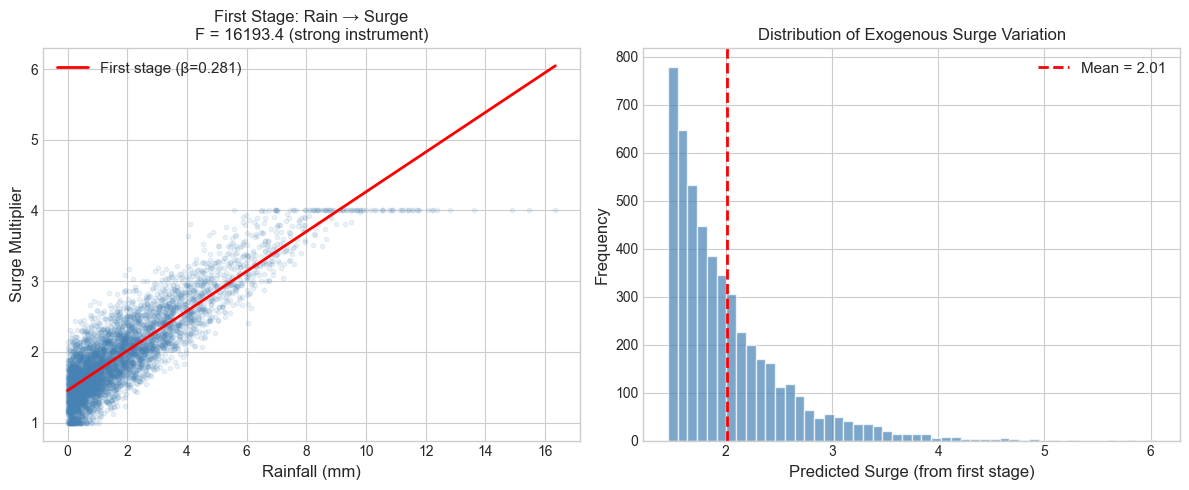

In [5]:
print("=" * 60)
print("FIRST STAGE REGRESSION: Surge ~ Rain")
print("=" * 60)
print(first_stage.summary())

# Visualize first stage
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Scatter: rain vs surge
axes[0].scatter(df['rain'], df['surge'], alpha=0.1, s=10, color='steelblue')
rain_range = np.linspace(df['rain'].min(), df['rain'].max(), 100)
axes[0].plot(rain_range, first_stage.params['const'] + first_stage.params['rain'] * rain_range,
             color='red', linewidth=2, label=f'First stage (β={first_stage.params["rain"]:.3f})')
axes[0].set_xlabel('Rainfall (mm)', fontsize=12)
axes[0].set_ylabel('Surge Multiplier', fontsize=12)
axes[0].set_title(f'First Stage: Rain → Surge\nF = {f_stat:.1f} (strong instrument)', fontsize=12)
axes[0].legend(fontsize=11)

# Distribution of predicted surge from first stage
surge_hat = first_stage.fittedvalues
axes[1].hist(surge_hat, bins=50, color='steelblue', alpha=0.7, edgecolor='white')
axes[1].axvline(surge_hat.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean = {surge_hat.mean():.2f}')
axes[1].set_xlabel('Predicted Surge (from first stage)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Distribution of Exogenous Surge Variation', fontsize=12)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

## Second Stage: 2SLS Estimation

Two-Stage Least Squares (2SLS):
1. **Stage 1**: Regress treatment on instrument → get predicted treatment (exogenous variation only)
2. **Stage 2**: Regress outcome on predicted treatment → get causal estimate

The predicted surge from Stage 1 contains ONLY variation driven by rain (the exogenous part), stripping out the confounded variation from event demand.

In [6]:
# === MANUAL 2SLS ===
# Stage 1: already done (first_stage)
surge_hat = first_stage.fittedvalues

# Stage 2: completions ~ surge_hat
X_second = sm.add_constant(surge_hat)
second_stage = sm.OLS(df['completion_rate'], X_second).fit()

print("=" * 60)
print("2SLS INSTRUMENTAL VARIABLES ESTIMATION")
print("=" * 60)

print(f"\n{'Method':<25} {'Estimate':<12} {'Bias':<12} {'95% CI'}")
print("-" * 65)
print(f"{'True Effect':<25} {TRUE_EFFECT:<12.4f} {'—':<12} —")
print(f"{'Naive OLS':<25} {ols_model.params['surge']:<12.4f} {ols_model.params['surge']-TRUE_EFFECT:<12.4f} [{ols_model.conf_int().loc['surge'][0]:.4f}, {ols_model.conf_int().loc['surge'][1]:.4f}]")
print(f"{'IV (2SLS)':<25} {second_stage.params.iloc[1]:<12.4f} {second_stage.params.iloc[1]-TRUE_EFFECT:<12.4f} [{second_stage.conf_int().iloc[1][0]:.4f}, {second_stage.conf_int().iloc[1][1]:.4f}]")

print(f"\n→ OLS is biased DOWNWARD (more negative) due to confounding.")
print(f"→ IV recovers an estimate close to the true effect of {TRUE_EFFECT}.")
print(f"→ IV has wider confidence intervals (price of using only exogenous variation).")

# Using statsmodels IV2SLS for proper standard errors
print(f"\n{'=' * 60}")
print("PROPER 2SLS (with correct standard errors)")
print(f"{'=' * 60}")
iv_result = IV2SLS(
    df['completion_rate'].values,
    sm.add_constant(df['surge']).values,
    sm.add_constant(df['rain']).values
).fit()
print(f"IV estimate: {iv_result.params[1]:.4f}")
print(f"Std Error:   {iv_result.bse[1]:.4f}")
print(f"Note: Manual 2SLS has incorrect SEs; use IV2SLS for proper inference.")

2SLS INSTRUMENTAL VARIABLES ESTIMATION

Method                    Estimate     Bias         95% CI
-----------------------------------------------------------------
True Effect               -0.1500      —            —
Naive OLS                 -0.1689      -0.0189      [-0.1714, -0.1663]
IV (2SLS)                 -0.1513      -0.0013      [-0.1557, -0.1469]

→ OLS is biased DOWNWARD (more negative) due to confounding.
→ IV recovers an estimate close to the true effect of -0.15.
→ IV has wider confidence intervals (price of using only exogenous variation).

PROPER 2SLS (with correct standard errors)
IV estimate: -0.1513
Std Error:   0.0015
Note: Manual 2SLS has incorrect SEs; use IV2SLS for proper inference.


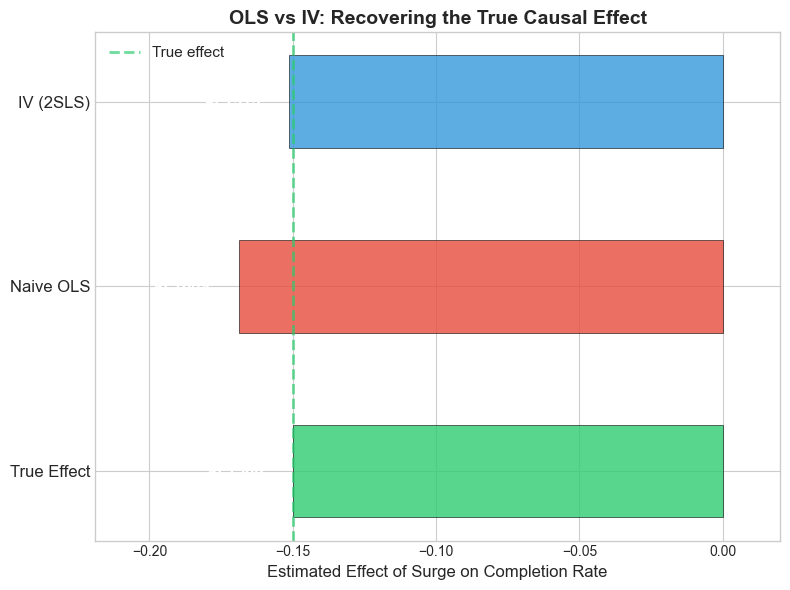


Key insight: OLS overestimates the negative effect by 0.0189
IV removes confounding bias and recovers the true price elasticity.


In [7]:
# === VISUALIZATION: OLS vs IV vs Truth ===
fig, ax = plt.subplots(figsize=(8, 6))

estimates = {
    'True Effect': TRUE_EFFECT,
    'Naive OLS': ols_model.params['surge'],
    'IV (2SLS)': second_stage.params.iloc[1]
}

colors = {'True Effect': '#2ecc71', 'Naive OLS': '#e74c3c', 'IV (2SLS)': '#3498db'}
y_positions = range(len(estimates))

for i, (method, estimate) in enumerate(estimates.items()):
    ax.barh(i, estimate, color=colors[method], alpha=0.8, height=0.5, edgecolor='black', linewidth=0.5)
    ax.text(estimate - 0.01, i, f'{estimate:.4f}', va='center', ha='right',
            fontsize=12, fontweight='bold', color='white')

ax.axvline(TRUE_EFFECT, color='#2ecc71', linestyle='--', linewidth=2, alpha=0.7, label='True effect')
ax.set_yticks(list(y_positions))
ax.set_yticklabels(list(estimates.keys()), fontsize=12)
ax.set_xlabel('Estimated Effect of Surge on Completion Rate', fontsize=12)
ax.set_title('OLS vs IV: Recovering the True Causal Effect', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xlim(min(estimates.values()) - 0.05, 0.02)

plt.tight_layout()
plt.show()

print(f"\nKey insight: OLS overestimates the negative effect by {abs(ols_model.params['surge'] - TRUE_EFFECT):.4f}")
print(f"IV removes confounding bias and recovers the true price elasticity.")

## The Weak Instrument Problem

What happens when the instrument barely predicts treatment? With a weak instrument (F < 10):
- IV estimate is biased **toward OLS** (defeating the purpose)
- Standard errors are unreliable
- Confidence intervals have wrong coverage

Let's demonstrate by creating a weak instrument and comparing results.

WEAK INSTRUMENT DEMONSTRATION

Instrument           F-stat     IV Estimate     Bias from True  Status
---------------------------------------------------------------------------
Strong (rain)        16193.4    -0.1513         0.0013          ✓ Valid
Weak (noisy)         0.0        0.5613          0.7113          ✗ Biased toward OLS
OLS (no IV)          —          -0.1689         0.0189          ✗ Confounded

⚠️  With F = 0.0 (< 10), the IV estimate drifts toward the biased OLS estimate.
   The weak instrument provides a FALSE sense of causal identification.


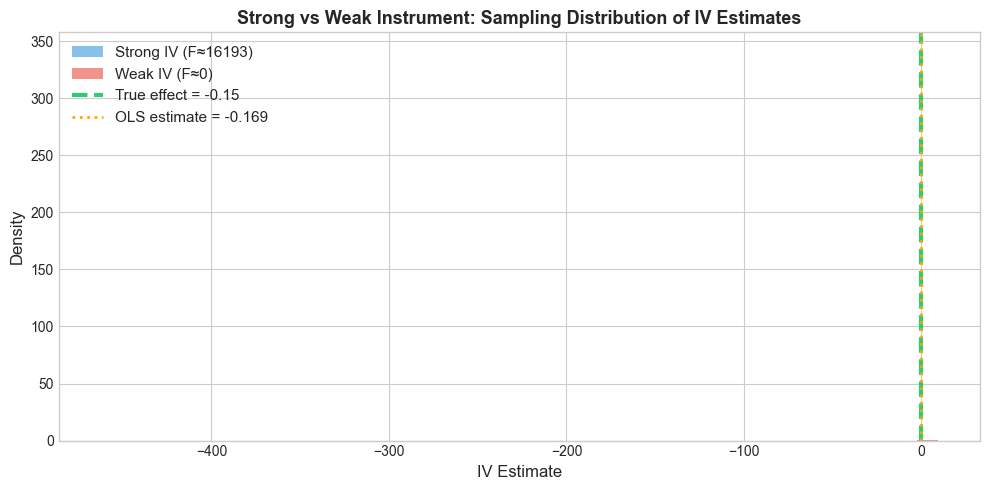


Strong IV: mean = -0.1500, std = 0.0015
Weak IV:   mean = -0.9839, std = 20.6766

Weak IV has higher variance AND is biased toward OLS.


In [8]:
# Create a WEAK instrument: barely predicts surge
weak_instrument = 0.02 * rain + np.random.normal(0, 3, n)  # mostly noise

# First stage with weak instrument
X_weak = sm.add_constant(weak_instrument)
first_stage_weak = sm.OLS(df['surge'], X_weak).fit()
f_stat_weak = first_stage_weak.fvalue

# IV with weak instrument
surge_hat_weak = first_stage_weak.fittedvalues
X_second_weak = sm.add_constant(surge_hat_weak)
second_stage_weak = sm.OLS(df['completion_rate'], X_second_weak).fit()

print("=" * 60)
print("WEAK INSTRUMENT DEMONSTRATION")
print("=" * 60)

print(f"\n{'Instrument':<20} {'F-stat':<10} {'IV Estimate':<15} {'Bias from True':<15} {'Status'}")
print("-" * 75)
print(f"{'Strong (rain)':<20} {f_stat:<10.1f} {second_stage.params.iloc[1]:<15.4f} {abs(second_stage.params.iloc[1]-TRUE_EFFECT):<15.4f} {'✓ Valid'}")
print(f"{'Weak (noisy)':<20} {f_stat_weak:<10.1f} {second_stage_weak.params.iloc[1]:<15.4f} {abs(second_stage_weak.params.iloc[1]-TRUE_EFFECT):<15.4f} {'✗ Biased toward OLS'}")
print(f"{'OLS (no IV)':<20} {'—':<10} {ols_model.params['surge']:<15.4f} {abs(ols_model.params['surge']-TRUE_EFFECT):<15.4f} {'✗ Confounded'}")

print(f"\n⚠️  With F = {f_stat_weak:.1f} (< 10), the IV estimate drifts toward the biased OLS estimate.")
print(f"   The weak instrument provides a FALSE sense of causal identification.")

# Monte Carlo: show bias distribution across simulations
n_sims = 500
iv_estimates_strong = []
iv_estimates_weak = []

for _ in range(n_sims):
    rain_sim = np.random.exponential(2.0, size=n)
    event_sim = np.random.beta(2, 5, size=n)
    surge_sim = 1.0 + 0.3 * rain_sim + 1.5 * event_sim + np.random.normal(0, 0.2, n)
    surge_sim = np.clip(surge_sim, 1.0, 4.0)
    comp_sim = 0.85 + TRUE_EFFECT * surge_sim - 0.20 * event_sim + np.random.normal(0, 0.05, n)

    # Strong IV
    X_s = sm.add_constant(rain_sim)
    fs_s = sm.OLS(surge_sim, X_s).fit()
    X_2s = sm.add_constant(fs_s.fittedvalues)
    iv_s = sm.OLS(comp_sim, X_2s).fit()
    iv_estimates_strong.append(iv_s.params[1])

    # Weak IV
    weak_z = 0.02 * rain_sim + np.random.normal(0, 3, n)
    X_w = sm.add_constant(weak_z)
    fs_w = sm.OLS(surge_sim, X_w).fit()
    X_2w = sm.add_constant(fs_w.fittedvalues)
    iv_w = sm.OLS(comp_sim, X_2w).fit()
    iv_estimates_weak.append(iv_w.params[1])

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(iv_estimates_strong, bins=40, alpha=0.6, color='#3498db', label=f'Strong IV (F≈{f_stat:.0f})', density=True)
ax.hist(iv_estimates_weak, bins=40, alpha=0.6, color='#e74c3c', label=f'Weak IV (F≈{f_stat_weak:.0f})', density=True)
ax.axvline(TRUE_EFFECT, color='#2ecc71', linewidth=3, linestyle='--', label=f'True effect = {TRUE_EFFECT}')
ax.axvline(ols_model.params['surge'], color='orange', linewidth=2, linestyle=':', label=f'OLS estimate = {ols_model.params["surge"]:.3f}')
ax.set_xlabel('IV Estimate', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Strong vs Weak Instrument: Sampling Distribution of IV Estimates', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"\nStrong IV: mean = {np.mean(iv_estimates_strong):.4f}, std = {np.std(iv_estimates_strong):.4f}")
print(f"Weak IV:   mean = {np.mean(iv_estimates_weak):.4f}, std = {np.std(iv_estimates_weak):.4f}")
print(f"\nWeak IV has higher variance AND is biased toward OLS.")

## Key Takeaways

### When IV Works
- You have unmeasured confounders that bias OLS
- A valid instrument exists: relevant (F > 10), excludable, independent
- You're comfortable with a **LATE** interpretation (effect on compliers only)

### When IV Doesn't Work
- No plausible instrument available (most common barrier)
- Instrument is weak (F < 10) → biased toward OLS with unreliable inference
- Exclusion restriction is violated (instrument has direct effect on outcome)
- You need ATE rather than LATE

### The LATE Interpretation
IV estimates the **Local Average Treatment Effect** — the causal effect for **compliers** (units whose treatment status is changed by the instrument). In our example:
- LATE = effect of surge on completions *for rides where surge was caused by rain*
- This may differ from the ATE if rain-induced surge affects different types of rides than event-induced surge

### Practical Checklist
1. ✅ Argue instrument validity (all three assumptions)
2. ✅ Report first-stage F-statistic (must be > 10)
3. ✅ Compare IV to OLS — if they're similar, maybe confounding isn't the issue
4. ✅ Report IV with proper standard errors (not manual 2SLS SEs)
5. ✅ Be explicit about LATE interpretation — who are the compliers?